# What is Deep Learning?

- A subset of ML which itself is a subset of AI.
- What is "deep"?
    - Circuits are typically organized in many layers.
    - computation paths from inputs to outputs have many steps.
- Rise of deep learning:
    - Data availability
    - Compute resources
    - Algorithmic innovation
- Performance v Data:
    - 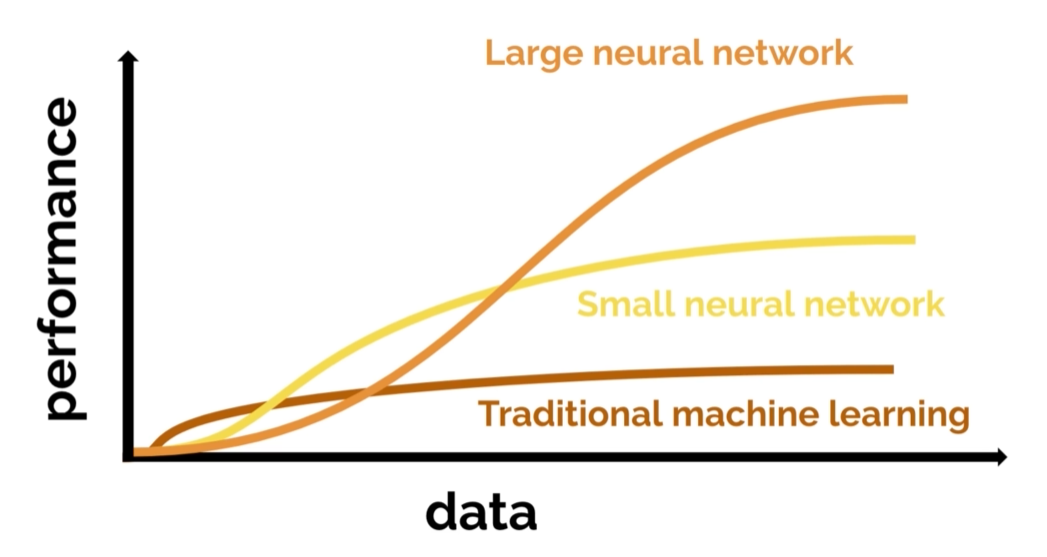
- How do you improve performance?
    - Increase training data
    - Increase neural network size
- Deep learning structure:
    - Multi layered structure called neural networks
- Basic idea of deep learning:
    - Train circuits with long computation paths
        - Allows all input variables to interact in complex ways
        - Each variable can interact with all others

---

# What is a Neural Network?

- Also known as artificial neural network.
- ML framework
- Mimics the learning pattern of the brain's neural networks
- Natural neural network:
    - Interconnected neurons that recieve inputs
    - Produce output signal through an axon to another neuron
- How to build an artificial neural network:
    - Input layer takes in feature inputs
    - Add hidden layers
    - Output layer makes outputs
    - 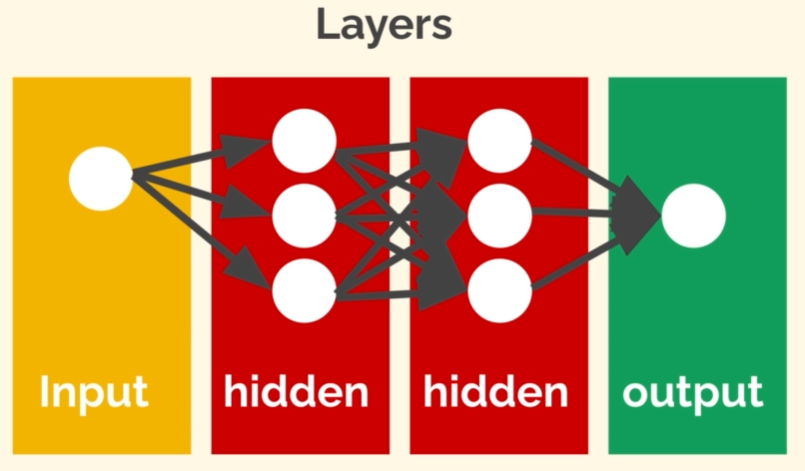
- What is a neuron?
    - Calculates weighted sum of inputs from predecessor neuron
    - Applies an activation function to produce its output
- How do you buld the layers?
    - Start with one perceptron
    - Add layers of perceptrons together
- What is a perceptron?
    - Receives inputs
    - Multiplies inputs by a random weight
    - Adds a bias to account for inputs of 0
    - Passess inputs to an activation function to produce an output
- What do you do with the output?
    - Compare the output to a known label
    - Adjust weight accordingly
    - Repeat until there are no more allowed iterations or the error rate is acceptable
- How do you build a perceptron?
    - Atleast 1 input
    - Bias
    - Activation function
    - 1 output
- Types of neural networks:
    - Feedforward (NN)
        - Connections only go in 1 direction
     - Convolutional (CNN)
        - Takes adjacency into account
        - Grid topology data (images)
     - Recurrent (RNN)
        - Feeds outpot back into its own inputs
        - Sequential data (language)
- Activation Function
- 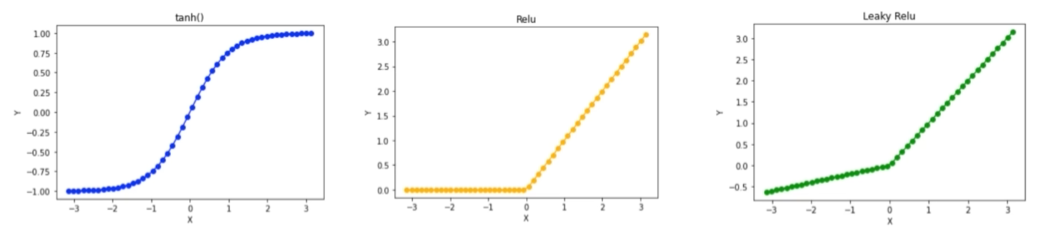
    - Nonlinear Function
        - Allows large networks of neurons to represent arbitrary functions. 

---

# Build a NN Classifier

In [2]:
# Load Stock Data with Yahoo Finance
import yfinance

symbol = "BTC-USD"

start = "2014-01-01"

end = "2021-01-01"

dataframe = yfinance.download(symbol, start, end)

[*********************100%***********************]  1 of 1 completed


In [3]:
dataframe

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2020-12-27,26272.294922,28288.839844,25922.769531,26439.373047,66479895605
2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893


In [7]:
#Save to csv file
dataframe.to_csv("btc-usd-2014-2021.csv")

In [9]:
import numpy as np

BUY = 1

SELL = 0

dataframe["Buy or Sell (Close)"] = np.where(dataframe["Close"].shift(-1) > dataframe["Close"],
                                            BUY,
                                            SELL)
dataframe

Price,Close,High,Low,Open,Volume,Buy or Sell (Close)
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
Date,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,1
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,1
...,...,...,...,...,...,...
2020-12-27,26272.294922,28288.839844,25922.769531,26439.373047,66479895605,1
2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,1


In [10]:
BUY = 1

SELL = 0

dataframe["Buy or Sell (Open)"] = np.where(dataframe["Open"].shift(-1) > dataframe["Open"],
                                            BUY,
                                            SELL)
dataframe

Price,Close,High,Low,Open,Volume,Buy or Sell (Close),Buy or Sell (Open)
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,
Date,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,0,0
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0,0
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,1,0
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,0,1
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,1,0
...,...,...,...,...,...,...,...
2020-12-27,26272.294922,28288.839844,25922.769531,26439.373047,66479895605,1,0
2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,1,1


In [11]:
#Calculate the amount of returns we are to get each day
dataframe["Returns"] = dataframe["Close"].pct_change()

dataframe

Price,Close,High,Low,Open,Volume,Buy or Sell (Close),Buy or Sell (Open),Returns
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,
Date,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,0,0,NaN
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0,0,-0.071926
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,1,0,-0.069843
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,0,1,0.035735
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,1,0,-0.024659
...,...,...,...,...,...,...,...,...
2020-12-27,26272.294922,28288.839844,25922.769531,26439.373047,66479895605,1,0,-0.006231
2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,1,1,0.030927


In [13]:
#Calculate whether the volume increased or decreased
INCREASE = 1

DECREASE = 0

dataframe["Volume Increase or Decrease"] = np.where(dataframe["Volume"].shift(-1) > dataframe["Volume"],
                                                    INCREASE,
                                                    DECREASE)
dataframe

Price,Close,High,Low,Open,Volume,Buy or Sell (Close),Buy or Sell (Open),Returns,Volume Increase or Decrease
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,
Date,,,,,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800,0,0,NaN,1
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0,0,-0.071926,1
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,1,0,-0.069843,0
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,0,1,0.035735,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,1,0,-0.024659,0
...,...,...,...,...,...,...,...,...,...
2020-12-27,26272.294922,28288.839844,25922.769531,26439.373047,66479895605,1,0,-0.006231,0
2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,1,1,0.030927,0


In [14]:
# Drop Null Values
dataframe = dataframe.dropna()

dataframe

Price,Close,High,Low,Open,Volume,Buy or Sell (Close),Buy or Sell (Open),Returns,Volume Increase or Decrease
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,,
Date,,,,,,,,,
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0,0,-0.071926,1
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,1,0,-0.069843,0
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,0,1,0.035735,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,1,0,-0.024659,0
2014-09-22,402.152008,406.915985,397.130005,399.100006,24127600,1,1,0.008352,1
...,...,...,...,...,...,...,...,...,...
2020-12-27,26272.294922,28288.839844,25922.769531,26439.373047,66479895605,1,0,-0.006231,0
2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,1,1,0.030927,0


---

### Build X and Y Train and Test Data

In [15]:
y = dataframe["Buy or Sell (Close)"]

y

Date
2014-09-18    0
2014-09-19    1
2014-09-20    0
2014-09-21    1
2014-09-22    1
             ..
2020-12-27    1
2020-12-28    1
2020-12-29    1
2020-12-30    1
2020-12-31    0
Name: Buy or Sell (Close), Length: 2297, dtype: int32

In [16]:
COLUMN_AXIS = 1

X = dataframe.drop(["Buy or Sell (Close)"], axis = COLUMN_AXIS)

X

Price,Close,High,Low,Open,Volume,Buy or Sell (Open),Returns,Volume Increase or Decrease
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,,,
Date,,,,,,,,
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200,0,-0.071926,1
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700,0,-0.069843,0
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600,1,0.035735,0
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100,0,-0.024659,0
2014-09-22,402.152008,406.915985,397.130005,399.100006,24127600,1,0.008352,1
...,...,...,...,...,...,...,...,...
2020-12-27,26272.294922,28288.839844,25922.769531,26439.373047,66479895605,0,-0.006231,0
2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,1,0.030927,0


In [17]:
#Split data for testing and training
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y)

In [18]:
X_train.shape

(1722, 8)

In [19]:
X_test.shape

(575, 8)

In [20]:
y_train.shape

(1722,)

In [21]:
y_test.shape

(575,)

In [22]:
#Scale Data to a range between -1 and +1
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler

StandardScaler()

In [23]:
scaler.fit(X_train)

StandardScaler()

In [24]:
X_train = scaler.transform(X_train)

X_train

array([[ 2.59960846,  2.5412211 ,  2.55282834, ...,  0.91209369,
         0.83098944, -0.95679759],
       [ 2.13825899,  2.14243435,  1.77451962, ...,  0.91209369,
         0.39488489, -0.95679759],
       [ 0.99667071,  0.9707417 ,  1.02844417, ...,  0.91209369,
         0.34359947, -0.95679759],
       ...,
       [-0.96710085, -0.9669601 , -0.97145803, ...,  0.91209369,
         0.03459404, -0.95679759],
       [-0.19324111, -0.20582668, -0.17018008, ..., -1.0963786 ,
        -0.09804741,  1.04515314],
       [ 1.36515603,  1.31888532,  1.42240995, ..., -1.0963786 ,
        -0.10115247,  1.04515314]])

In [25]:
X_test = scaler.transform(X_test)

X_test

array([[-0.94714404, -0.94631449, -0.95102582, ...,  0.91209369,
         0.06371565,  1.04515314],
       [-0.95929855, -0.95910515, -0.96494623, ...,  0.91209369,
         0.70315983,  1.04515314],
       [-0.82981391, -0.83092204, -0.83391654, ..., -1.0963786 ,
        -0.29571527, -0.95679759],
       ...,
       [-0.82882452, -0.83068576, -0.82942654, ...,  0.91209369,
         0.07059203,  1.04515314],
       [ 0.9935126 ,  0.97716005,  1.04366634, ..., -1.0963786 ,
        -0.3397811 , -0.95679759],
       [ 3.83672227,  3.72283958,  3.71899722, ...,  0.91209369,
         1.01658741,  1.04515314]])

In [26]:
y_test

Date
2014-11-03    1
2015-03-22    0
2017-01-09    1
2017-12-02    1
2018-04-07    1
             ..
2016-03-11    0
2016-04-06    0
2017-01-10    0
2020-05-08    0
2020-12-22    0
Name: Buy or Sell (Close), Length: 575, dtype: int32

---

### Build a Neural Network Classifier

In [29]:
from sklearn.neural_network import MLPClassifier

NUMBER_OF_NODES = 10

NUMBER_OF_LOOPS = 500

model = MLPClassifier(hidden_layer_sizes = (NUMBER_OF_NODES,
                                           NUMBER_OF_NODES,
                                           NUMBER_OF_NODES),
                      max_iter = NUMBER_OF_LOOPS)
model

MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=500)

In [30]:
model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=500)

In [31]:
#Evaluate model
predicted_y = model.predict(X_test)

predicted_y

array([1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,

In [33]:
# Model Accuracy and Confusion Matrix
from sklearn.metrics import confusion_matrix

results_matrix = confusion_matrix(y_test, predicted_y)

results_matrix

array([[117, 130],
       [115, 213]], dtype=int64)

In [34]:
results_matrix.trace()

330

In [35]:
results_matrix.sum()

575

In [36]:
def calculate_accuracy_from_matrix(matrix):
    diagonal_sum = matrix.trace()
    sum_of_all_values = matrix.sum()
    accuracy = diagonal_sum / sum_of_all_values
    return accuracy

In [38]:
calculate_accuracy_from_matrix(results_matrix)

0.5739130434782609

In [40]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, predicted_y))

              precision    recall  f1-score   support

           0       0.50      0.47      0.49       247
           1       0.62      0.65      0.63       328

    accuracy                           0.57       575
   macro avg       0.56      0.56      0.56       575
weighted avg       0.57      0.57      0.57       575

